In [92]:
import pandas as pd
import pathlib
import rootutils
import torch

rootutils.setup_root(".", indicator=".project-root", pythonpath=True)

from matplotlib import pyplot as plt
from matplotlib import patches

from src.core.data.rainforest_connection import RainforestConnection
from src.core.models.vae import VAE
from src.core.models.sivae import SIVAE
from src.core.evaluators.translation_invariance_figure import designal

In [93]:
checkpoint_dir = pathlib.Path("/its/home/kag25/models/v1/")
model_name = "vae/misty-lecture/"
checkpoint_path = "step=180000.ckpt"
model = VAE.load_from_checkpoint(checkpoint_dir / model_name / checkpoint_path, map_location="cpu")
# model_name = "sivae/mossy-andrea/"
# model = SIVAE.load_from_checkpoint(checkpoint_dir / model_name / checkpoint_path, map_location="cpu")

In [94]:
data_dir = pathlib.Path("/its/home/kag25/data/rainforest_connection")
data = RainforestConnection(root=data_dir, sort_index=True)
labels = data.strong_labels.sort_index()
labels["t_min_hops"] = labels["t_min"].map(model.front_end.seconds_to_hops)
labels["t_max_hops"] = labels["t_max"].map(model.front_end.seconds_to_hops)
labels["f_min_bin"] = labels["f_min"].map(model.front_end.hz_to_mel_bin)
labels["f_max_bin"] = labels["f_max"].map(model.front_end.hz_to_mel_bin)

In [95]:
species = "Turdus plumbeus_Red-legged Thrush"
species_labels = labels[labels.species_name == species]
species_labels.head()

,file_name,species_id,songtype_id,t_min,f_min,t_max,f_max,species_name,taxa,t_min_hops,t_max_hops,f_min_bin,f_max_bin
file_i,,,,,,,,,,,,,
76,5a55970ad.flac,17,1,19.9787,1312.5,26.4320,3937.5,Turdus plumbeus_Red-legged Thrush,bird,2497,3304,14,32
179,1263c23c8.flac,17,1,38.9013,1312.5,45.3547,3937.5,Turdus plumbeus_Red-legged Thrush,bird,4862,5669,14,32
421,3c621e663.flac,17,1,2.8053,1312.5,9.2587,3937.5,Turdus plumbeus_Red-legged Thrush,bird,350,1157,14,32
421,3c621e663.flac,17,1,20.5973,1312.5,27.0507,3937.5,Turdus plumbeus_Red-legged Thrush,bird,2574,3381,14,32
421,3c621e663.flac,17,1,49.7920,1312.5,56.2453,3937.5,Turdus plumbeus_Red-legged Thrush,bird,6224,7030,14,32


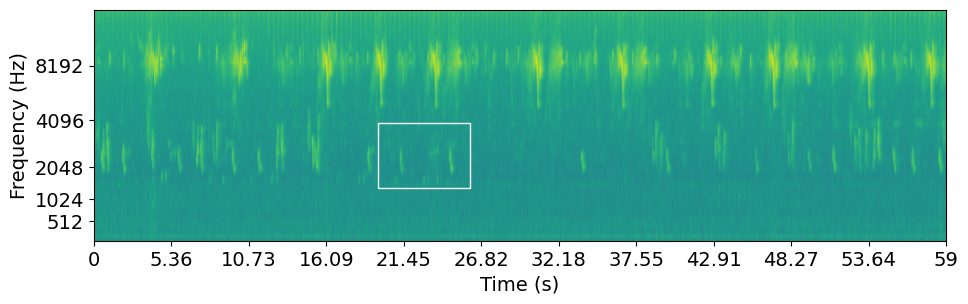

torch.Size([64, 7488])

In [116]:
i = 0
row = species_labels.iloc[i]
x = model.pre_process(data.load_sample(row.file_name)).squeeze()
fig, ax = plt.subplots(figsize=(11, 3))
model.front_end.plot(x)
rect = patches.Rectangle([row.t_min_hops, row.f_min_bin], row.t_max_hops - row.t_min_hops, row.f_max_bin - row.f_min_bin, linewidth=1, edgecolor="white", facecolor='none', zorder=10)
ax.add_patch(rect)
plt.show()
x.shape

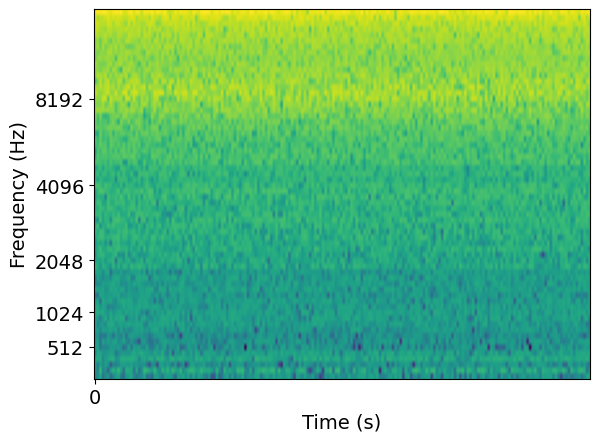

In [97]:
x_renoised = designal(x.t())[:192]
model.front_end.plot(x_renoised.t())
plt.show()

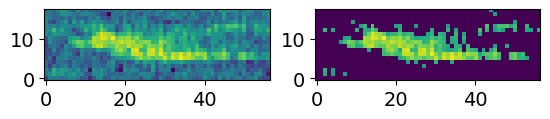

In [98]:
t_i, t_j, f_i, f_j = row.t_min_hops + 610, row.t_max_hops - 140, row.f_min_bin, row.f_max_bin
signal = x[f_i:f_j, t_i:t_j]
f, t = signal.size()
fig, (ax1, ax2) = plt.subplots(ncols=2)
ax1.imshow(signal, origin="lower")
threshold = -2
min_val = signal.min()
sig_thresh = torch.where(signal > threshold, signal, min_val)
ax2.imshow(sig_thresh, origin="lower")
plt.show()

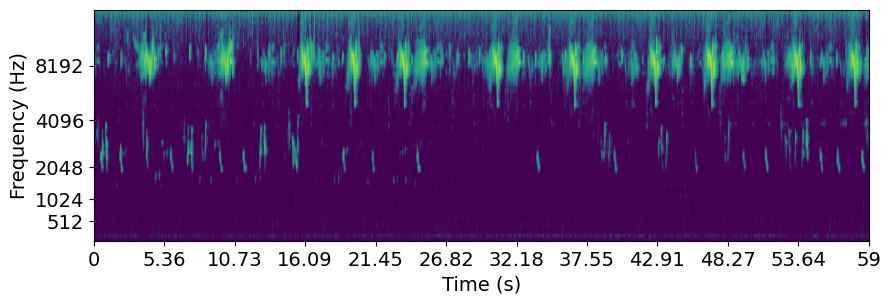

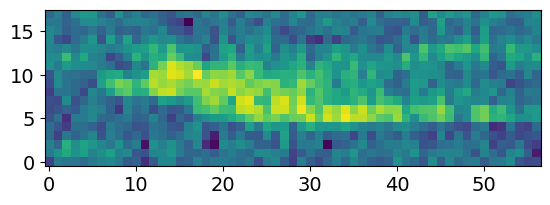

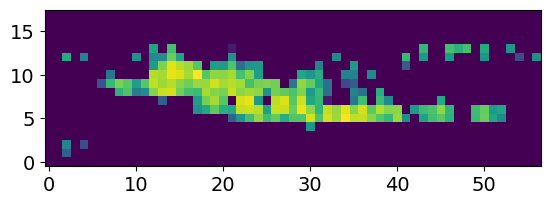

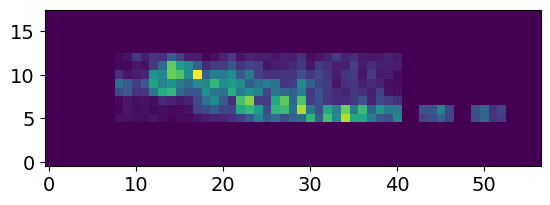

In [99]:
import librosa
import numpy as np
import scipy.ndimage as ndi
from skimage.measure import label, regionprops

epsilon = 1e-8
percentile = 30
noise_reduction_factor = 2.5
threshold_std = 0.2
S_mag = x.t().exp()
# per-frequency noise floor estimate using low-percentile statistics
noise_floor = np.percentile(S_mag, percentile, axis=1)
# soft spectral gating, S'(f,t) = max(S(f,t) - lambda*N(f), 0)
S_denoised = np.maximum(S_mag - (noise_reduction_factor * noise_floor[:, np.newaxis]), epsilon)
S_db = librosa.amplitude_to_db(S_denoised, ref=np.max)
plt.figure(figsize=(10, 3))
model.front_end.plot(S_db.T)
plt.show()
plt.figure()
plt.imshow(np.log(S_mag[t_i:t_j, f_i:f_j]).T, origin="lower")
plt.show()

plt.figure()
plt.imshow(S_db[t_i:t_j, f_i:f_j].T, origin="lower")
plt.show()

thresh = (np.mean(S_db) + threshold_std * np.std(S_db))
binary_mask = S_db[t_i:t_j, f_i:f_j] > thresh
binary_mask = ndi.binary_opening(binary_mask, structure=np.ones((2, 2)))
labeled = label(binary_mask, connectivity=1)
regions = regionprops(labeled)

signal = S_mag[t_i:t_j, f_i:f_j].numpy()
mask = np.zeros(signal.shape)
for region in regions:
    t1, f1, t2, f2 = region.bbox
    mask[t1:t2, f1:f2] = 1
segmented = signal * mask
seg_signal = np.maximum(segmented, 0.1)
plt.figure()
plt.imshow(segmented.T, origin="lower")
plt.show()


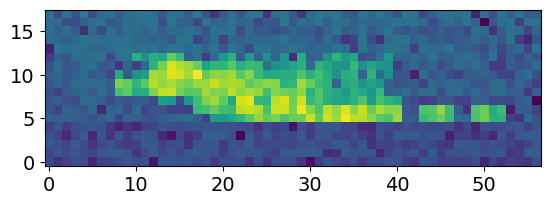

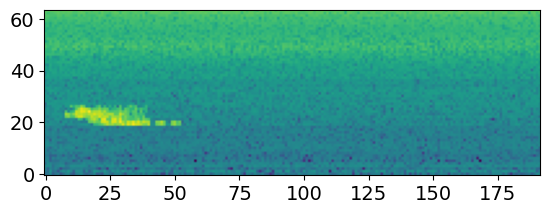

In [100]:
log_seg = np.log(seg_signal)
background = x_renoised.clone().numpy()
bg = background[:, f_i:f_j]
for f in range(bg.shape[1]):
    fq = bg[:, f]
    for t in range(seg_signal.shape[0]):
        if seg_signal[t, f] <= 0.1:
            log_seg[t, f] = np.random.choice(fq)

plt.figure()
plt.imshow(log_seg.T, origin="lower")
plt.show()

background[0:log_seg.shape[0], f_i:f_j] = log_seg
plt.figure()
plt.imshow(background.T, origin="lower")
plt.show()


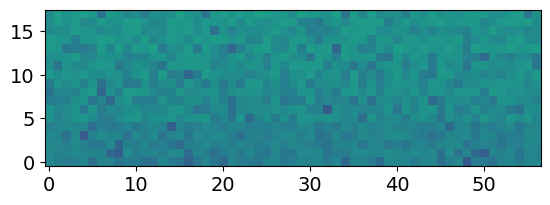

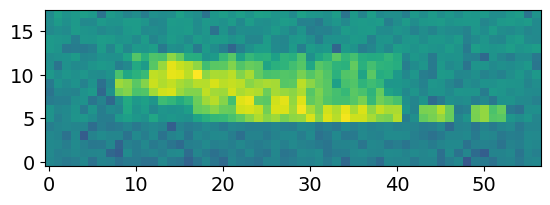

In [105]:
log_noise_seg = np.zeros_like(seg_signal)
background = x_renoised.clone().numpy()
bg = background[:, f_i:f_j]
for f in range(bg.shape[1]):
    fq = bg[:, f]
    for t in range(segmented.shape[0]):
        log_noise_seg[t, f] = np.random.choice(fq)

vin = min(log_noise_seg.min(), np.log(segmented + 1e-8).min())
vmax = max(log_noise_seg.max(), np.log(segmented + 1e-8).max())
plt.imshow(log_noise_seg.T, origin="lower", vmin=vmin, vmax=vmax)
plt.show()
plt.imshow(np.maximum(np.log(segmented + 1e-8), log_noise_seg).T, origin="lower", vmin=vmin, vmax=vmax)
plt.show()

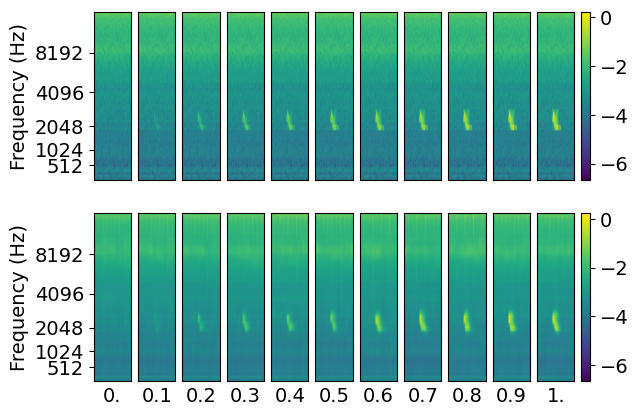

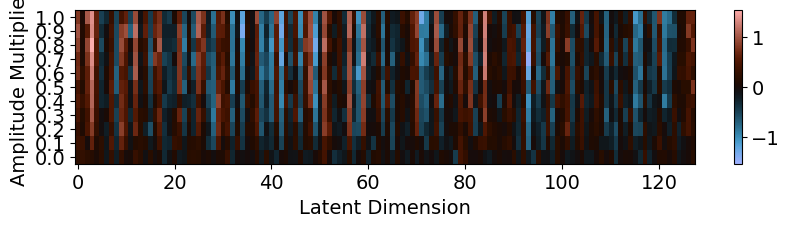

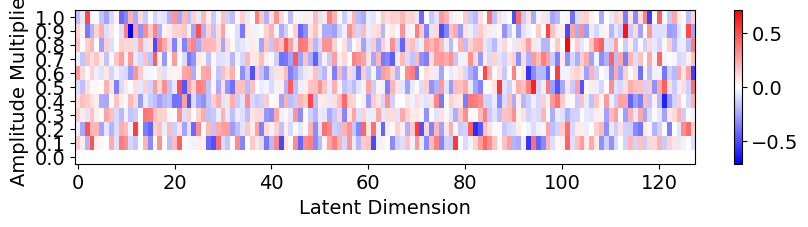

In [109]:
n = 11
amps = torch.linspace(0.0, 1.0, n)
fig, axes = plt.subplots(nrows=2, ncols=len(amps) + 1, width_ratios=[*[(1-0.02)/n]*n, 0.02])

xs = []
x_hats = []
zs = []

with torch.no_grad():
    background = x_renoised.clone().numpy()
    background[shift:log_seg.shape[0]+shift, f_i:f_j] = log_noise_seg
    x_bg = torch.tensor(background).view(1, 1, *background.shape)
    z_bg = model.encode(x_bg)[0].chunk(2, dim=-1)[0]

    for i, amp in enumerate(amps):
        background = x_renoised.clone().numpy()
        bg = background[:, f_i:f_j]
        shift = 192//2 - segmented.shape[0] // 2
        background[shift:segmented.shape[0] + shift, f_i:f_j] = np.maximum(np.log((amp * segmented) + 1e-10), log_noise_seg)
        x = torch.tensor(background).view(1, 1, *background.shape)
        xs.append(x)
        q_z, *_ = model.encode(x)
        mu_z, _ = q_z.chunk(2, dim=-1)
        zs.append(mu_z)
        x_hat = model.decode(mu_z)
        x_hats.append(x_hat)

xs = torch.stack(xs, dim=0)
x_hats = torch.stack(x_hats, dim=0)
vmin, vmax = min(xs.min(), x_hats.min()), max(xs.max(), x_hats.max())
for i, amp in enumerate(amps):
    model.front_end.plot(xs[i].squeeze().t(), ax=axes[0, i], vmin=vmin, vmax=vmax)
    mesh = model.front_end.plot(x_hats[i].squeeze().t(), ax=axes[1, i], vmin=vmin, vmax=vmax)
    if i > 0:
        axes[0, i].set_ylabel("")
        axes[1, i].set_ylabel("")
        axes[0, i].tick_params(labelleft=False, left=False)
        axes[1, i].tick_params(labelleft=False, left=False)
    axes[0, i].set_xlabel("")
    axes[1, i].set_xlabel(np.format_float_positional(amp, precision=1))
    axes[0, i].tick_params(labelbottom=False, bottom=False)
    axes[1, i].tick_params(labelbottom=False, bottom=False)
    if i == len(amps) - 1:
        plt.colorbar(mesh, cax=axes[0, -1])
        plt.colorbar(mesh, cax=axes[1, -1])

plt.show()

fig, ax = plt.subplots(figsize=(10, 2))
zs = torch.stack(zs, dim=0) - z_bg
bound = max(zs.max().abs(), zs.min().abs())
im = ax.imshow(zs.squeeze().numpy(), vmin=-bound, vmax=bound, origin="lower", aspect="auto", cmap="berlin")
ax.set_yticks(range(len(amps)), labels=amps.numpy())
ax.set_ylabel("Amplitude Multiplier")
ax.set_xlabel("Latent Dimension")
fig.colorbar(im, ax=ax)
plt.show()

fig, ax = plt.subplots(figsize=(10, 2))
dzdA = zs.diff(dim=0, prepend=zs[0:1, :])
bound = max(dzdA.max().abs(), dzdA.min().abs())
im = ax.imshow(dzdA.squeeze().numpy(), vmin=-bound, vmax=bound, origin="lower", aspect="auto", cmap="bwr")
ax.set_yticks(range(len(amps)), labels=amps.numpy())
ax.set_ylabel("Amplitude Multiplier")
ax.set_xlabel("Latent Dimension")
fig.colorbar(im, ax=ax)
plt.show()

In [86]:
np.testing.assert_allclose(np.maximum(np.log(segmented * 0.0 + 1e-10), log_noise_seg), log_noise_seg)

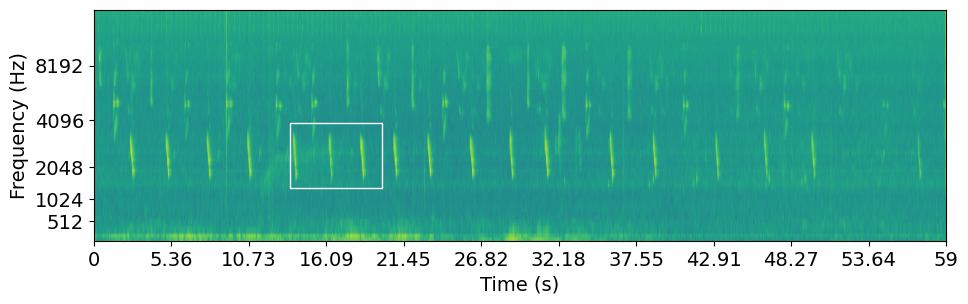

torch.Size([64, 7488])

In [151]:
i = 6
row = species_labels.iloc[i]
x = model.pre_process(data.load_sample(row.file_name)).squeeze()
fig, ax = plt.subplots(figsize=(11, 3))
model.front_end.plot(x)
rect = patches.Rectangle([row.t_min_hops, row.f_min_bin], row.t_max_hops - row.t_min_hops, row.f_max_bin - row.f_min_bin, linewidth=1, edgecolor="white", facecolor='none', zorder=10)
ax.add_patch(rect)
plt.show()
x.shape

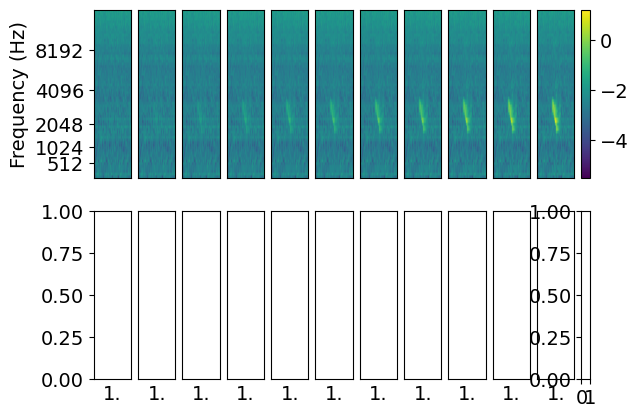

In [182]:
x_fg = x[:, 6294:6342]
l = x_fg.shape[-1]
x_bg = torch.cat([x[:, 6800:6800+l], x[:, 6800:6800+l], x[:, 6800:6800+l], x[:, 6800:6800+l]], dim=-1)
L = x_bg.shape[-1]
p = torch.randperm(x_bg.size(-1))
x_bg = x_bg[:, p]
fig, axes = plt.subplots(nrows=2, ncols=len(amps) + 1, width_ratios=[*[(1-0.02)/n]*n, 0.02])
alphas = np.linspace(0, 1, 11)
xs = []
for i, alpha in enumerate(alphas):
    ti = L // 2 - l//2
    tj = L // 2 + l//2
    x1 = x_bg.clone()
    x1[:, ti:tj] = (1 - alpha) * x1[:, ti:tj] + alpha * x_fg
    xs.append(x1)

xs = torch.stack(xs, dim=0)
for i, alpha in enumerate(alphas):
    mesh = model.front_end.plot(xs[i], ax=axes[0, i], vmin=xs.min(), vmax=xs.max())
    if i > 0:
        axes[0, i].set_ylabel("")
        axes[1, i].set_ylabel("")
        axes[0, i].tick_params(labelleft=False, left=False)
        axes[1, i].tick_params(labelleft=False, left=False)
    axes[0, i].set_xlabel("")
    axes[1, i].set_xlabel(np.format_float_positional(amp, precision=1))
    axes[0, i].tick_params(labelbottom=False, bottom=False)
    axes[1, i].tick_params(labelbottom=False, bottom=False)
    if i == len(alphas) - 1:
        plt.colorbar(mesh, cax=axes[0, -1])
        # plt.colorbar(mesh, cax=axes[1, -1])


torch.Size([64, 192])